**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
Erick Gabriel Santiago Suenaga

## Práctica 2: Procesamiento de datatasets
---

## Contexto y procedencia del dataset

El dataset contiene el catálogo de alojamientos de corta estancia publicados en Airbnb en la Ciudad de México. Cada fila describe un anuncio: dónde está (alcaldía y coordenadas), qué tipo de espacio ofrece, cuánto cuesta por noche, qué estancia mínima exige, cuántas noches tiene disponibles en su calendario y qué tanta actividad de reseñas tiene. También indica cuántos anuncios tiene el anfitrión en la ciudad.

Fue recolectado por Inside Airbnb, un proyecto independiente y sin afiliación a Airbnb que compila la información pública del sitio de Airbnb y la publica como datos abiertos. Como no son datos entregados por la plataforma, sino una captura de lo que se ve públicamente, se deben considerar con esa limitación en mente: el precio es el precio publicado, no el que efectivamente se pagó, y un anuncio puede haber cambiado o desaparecido después de la captura.

| Elemento | Detalle |
|---|---|
| **Fuente** | Inside Airbnb, sección *Get the Data* (insideairbnb.com/get-the-data) |
| **Archivo** | `listings.csv` ("Summary information and metrics for listings"), no la versión detallada `listings.csv.gz` |
| **Fecha de recolección** | 15 de junio de 2026 (fecha incluida en el enlace de descarga) |
| **Unidad de observación** | Un anuncio (*listing*) de Airbnb en la Ciudad de México |
| **Qué mide** | Precio por noche (en moneda local, pesos mexicanos), estancia mínima, disponibilidad a 365 días, reseñas y número de anuncios del anfitrión |
| **Licencia** | Creative Commons Attribution 4.0 International (CC BY 4.0), según la página de descarga, consultada en octubre de 2026 |
| **Enlace de descarga** | https://data.insideairbnb.com/mexico/df/mexico-city/2026-06-15/visualisations/listings.csv |
| **Diccionario de datos** | Publicado por Inside Airbnb |

El archivo se usa sin modificaciones previas. Todas las correcciones se hacen más adelante, en la sección de limpieza, sobre una copia.

## Preparación del entorno

Se usan `numpy` y `pandas` para los datos, y `matplotlib` y `seaborn` para las gráficas. Se define una paleta de colores y algunas opciones de estilo para mantener coherencia visual en todas las figuras.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
AZUL_OSCURO = "#112057"
AZUL = "#4C72B0"
AZUL_CLARO = "#A9C4E8"
ROJO = "#C0392B"

sns.set_theme(style="whitegrid", palette=[AZUL_OSCURO, AZUL, AZUL_CLARO, ROJO])
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlecolor"] = AZUL_OSCURO

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

## Carga de datos

El archivo `listings.csv` es la descarga directa del enlace descrito arriba. Debe estar en la misma carpeta que este notebook.

In [3]:
df = pd.read_csv("listings.csv")

print("Filas y columnas:", df.shape)
df.head(3)

Filas y columnas: (31430, 19)


,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1698274831948209016,Roma Residence | Luxury Suite 305,471105419,1.470125e+18,Manuel,NaN,Cuauhtémoc,19.406572,-99.163091,Entire home/apt,2066.0,1.0,0,NaN,NaN,42,365,0,NaN
1,1120444645818769896,Grande y bonita habitación con cocina y baño,548898239,1.470455e+18,Catu,NaN,Benito Juárez,19.394448,-99.163367,Entire home/apt,628.0,1.0,0,NaN,NaN,1,257,0,NaN
2,1414477907775396874,Ven a sentirte como en casa.,49281983,1.465751e+18,Mireya,NaN,Coyoacán,19.339362,-99.185070,Private room,499.0,1.0,0,NaN,NaN,2,158,0,NaN


## Verificación de estructura y cumplimiento de requisitos

In [4]:
print("=" * 70)
print("VERIFICACIÓN DE REQUISITOS MÍNIMOS DEL DATASET")
print("=" * 70)

# 1) Tamaño
n_filas, n_cols = df.shape
print("\n1) Registros y atributos")
print(f"   Filas: {n_filas:,} | Columnas: {n_cols}")
print(f"   ¿Cumple (>=500 filas y >=10 columnas)? {n_filas >= 500 and n_cols >= 10}")

# 2) Tipos. Las columnas totalmente vacías las lee pandas como float64, pero no aportan información
vacias = [c for c in df.columns if df[c].isna().all()]
num_cols = [c for c in df.select_dtypes(include="number").columns if c not in vacias]
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
print("\n2) Tipos de atributos")
print(f"   Columnas completamente vacías ({len(vacias)}): {vacias}")
print(f"   Numéricos ({len(num_cols)}): {num_cols}")
print(f"   Categóricos / texto ({len(cat_cols)}): {cat_cols}")
print(f"   ¿Cumple (>=2 numéricos y >=2 categóricos)? {len(num_cols) >= 2 and len(cat_cols) >= 2}")

# 3) Variable objetivo
print("\n3) Variable objetivo candidata")
print("   price: precio por noche en pesos mexicanos (numérica continua)")
print(f"   Rango observado: {df['price'].min():,.0f} a {df['price'].max():,.0f} | valores presentes: {df['price'].notna().sum():,}")

# 4) Condiciones de datos reales
n_faltantes = int(df.isna().sum().sum())
n_dup_sin_id = int(df.drop(columns="id").duplicated().sum())
print("\n4) Datos reales con al menos un problema de calidad")
print(f"   Celdas vacías: {n_faltantes:,} (incluye {len(vacias)} columnas 100% vacías)")
print(f"   Registros idénticos salvo el id: {n_dup_sin_id}")
print(f"   Precios mayores a 50,000 MXN por noche: {(df['price'] > 50000).sum()}")
print(f"   ¿Cumple (al menos una condición)? {n_faltantes > 0 or n_dup_sin_id > 0}")

# 5) Procedencia
procedencia = {
    "Fuente": "Inside Airbnb (insideairbnb.com/get-the-data)",
    "Fecha de recolección": "15 de junio de 2026",
    "Unidad de observación": "un anuncio de Airbnb en la Ciudad de México",
    "Licencia": "CC BY 4.0",
    "Enlace": "https://data.insideairbnb.com/mexico/df/mexico-city/2026-06-15/visualisations/listings.csv",
}
print("\n5) Procedencia verificable")
for clave, valor in procedencia.items():
    print(f"   {clave}: {valor}")

VERIFICACIÓN DE REQUISITOS MÍNIMOS DEL DATASET

1) Registros y atributos
   Filas: 31,430 | Columnas: 19
   ¿Cumple (>=500 filas y >=10 columnas)? True

2) Tipos de atributos
   Columnas completamente vacías (2): ['neighbourhood_group', 'license']
   Numéricos (12): ['id', 'host_id', 'host_profile_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']
   Categóricos / texto (5): ['name', 'host_name', 'neighbourhood', 'room_type', 'last_review']
   ¿Cumple (>=2 numéricos y >=2 categóricos)? True

3) Variable objetivo candidata
   price: precio por noche en pesos mexicanos (numérica continua)
   Rango observado: 19 a 1,141,520 | valores presentes: 29,637

4) Datos reales con al menos un problema de calidad
   Celdas vacías: 75,671 (incluye 2 columnas 100% vacías)
   Registros idénticos salvo el id: 10
   Precios mayores a 50,000 MXN por noche: 79
   ¿Cumple (al menos

El dataset tiene 31,430 registros y 19 columnas, 12 atributos numéricos con contenido y 5 de texto. Las dos columnas completamente vacías, `neighbourhood_group` y `license`, no se cuentan.Varios "numéricos" son identificadores (`id`, `host_id`, `host_profile_id`) o coordenadas, no medidas. Los atributos que realmente se analizan como categóricos son `neighbourhood` (alcaldía) y `room_type` (tipo de alojamiento).

La variable objetivo candidata es `price`. Hay problemas de calidad: columnas 100% vacías, faltantes en el precio, registros idénticos salvo el `id` y precios extremos.

### Dimensiones y tipo de cada atributo

In [5]:
tipos = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "no_nulos": df.notna().sum(),
    "únicos": df.nunique(),
})
tipos

,tipo,no_nulos,únicos
id,int64,31430,31430
name,object,31430,29847
host_id,int64,31430,14107
host_profile_id,float64,31426,14106
host_name,object,31425,5040
neighbourhood_group,float64,0,0
neighbourhood,object,31430,16
latitude,float64,31430,20792
longitude,float64,31430,19539
room_type,object,31430,4


**Diccionario de columnas** (basado en el diccionario de datos de Inside Airbnb)

| Columna | Descripción |
|---|---|
| `id` | Identificador único del anuncio |
| `name` | Título del anuncio (texto libre) |
| `host_id` | Identificador del anfitrión |
| `host_profile_id` | Identificador del perfil del anfitrión |
| `host_name` | Nombre del anfitrión |
| `neighbourhood_group` | Agrupación de barrios (en este archivo viene vacía) |
| `neighbourhood` | Alcaldía del anuncio, asignada con sus coordenadas contra límites geográficos públicos |
| `latitude`, `longitude` | Coordenadas del anuncio |
| `room_type` | Tipo de alojamiento: casa o departamento completo, cuarto privado, cuarto compartido o cuarto de hotel |
| `price` | Precio diario en moneda local (pesos mexicanos) |
| `minimum_nights` | Estancia mínima en noches que exige el anuncio |
| `number_of_reviews` | Total de reseñas del anuncio |
| `last_review` | Fecha de la última reseña (texto con formato de fecha) |
| `reviews_per_month` | Reseñas promedio por mes |
| `calculated_host_listings_count` | Número de anuncios que tiene el anfitrión en la ciudad |
| `availability_365` | Noches disponibles en el calendario durante los próximos 365 días |
| `number_of_reviews_ltm` | Reseñas recibidas en los últimos 12 meses |
| `license` | Número de licencia o registro del anuncio (en este archivo viene vacía) |

Observaciones sobre los tipos: `neighbourhood_group` y `license` aparecen como `float64` solo porque están completamente vacías. `host_profile_id` es `float64` porque tiene cuatro faltantes, y eso es un problema: son números de 19 dígitos, por lo que un `float64` ya no los representa con exactitud. `last_review` es texto y debería ser fecha.

## Calidad de los datos

En esta sección solo se detectan los problemas. Las correcciones se hacen más adelante, en la sección de limpieza.

### Patrón de valores faltantes

In [6]:
faltantes = pd.DataFrame({"n_faltantes": df.isna().sum()})
faltantes["%"] = (faltantes["n_faltantes"] / len(df) * 100).round(2)
faltantes = faltantes[faltantes["n_faltantes"] > 0].sort_values("n_faltantes", ascending=False)
faltantes

,n_faltantes,%
neighbourhood_group,31430,100.00
license,31430,100.00
last_review,5499,17.50
reviews_per_month,5499,17.50
price,1793,5.70
minimum_nights,11,0.03
host_name,5,0.02
host_profile_id,4,0.01


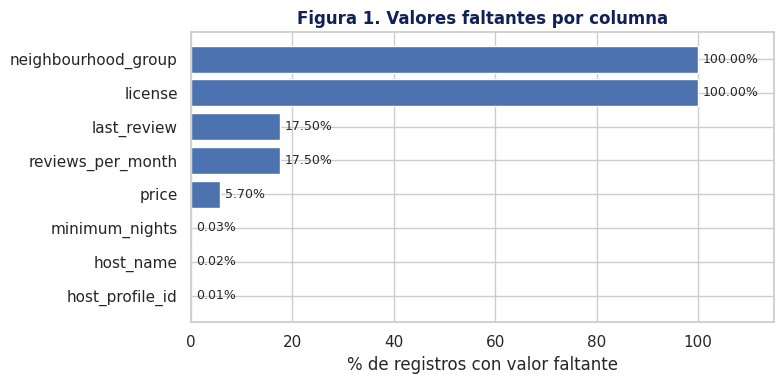

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(faltantes.index[::-1], faltantes["%"][::-1], color=AZUL)
for i, v in enumerate(faltantes["%"][::-1]):
    ax.text(v + 1, i, f"{v:.2f}%", va="center", fontsize=9)
ax.set_xlim(0, 115)
ax.set_xlabel("% de registros con valor faltante")
ax.set_title("Figura 1. Valores faltantes por columna")
plt.tight_layout()
plt.show()

**Figura 1.** Dos columnas están 100% vacías (`neighbourhood_group` y `license`) y no aportan información. `last_review` y `reviews_per_month` faltan exactamente en 5,499 anuncios (17.5%), y `price` falta en 1,793 (5.7%). El resto es marginal: `minimum_nights` (11 anuncios), `host_name` (5) y `host_profile_id` (4).

Conviene revisar si esos faltantes son azar o tienen una causa.

In [8]:
# ¿Los vacíos de last_review y reviews_per_month coinciden con los anuncios sin reseñas?
sin_resenas = df["number_of_reviews"] == 0
print("Anuncios con 0 reseñas:", sin_resenas.sum())
print("reviews_per_month vacío:", df["reviews_per_month"].isna().sum())
print("last_review vacío:", df["last_review"].isna().sum())
coinciden = (df["reviews_per_month"].isna() == sin_resenas).all() and (df["last_review"].isna() == sin_resenas).all()
print("¿Coinciden exactamente con los anuncios sin reseñas?", coinciden)

Anuncios con 0 reseñas: 5499
reviews_per_month vacío: 5499
last_review vacío: 5499
¿Coinciden exactamente con los anuncios sin reseñas? True


Los 5,499 vacíos coinciden uno a uno con los anuncios que tienen cero reseñas. No son datos perdidos: un anuncio sin reseñas no tiene fecha de última reseña ni tasa mensual, así que la información simplemente no existe todavía.

Ahora se revisa el faltante del precio, que es el más importante porque `price` es la variable objetivo candidata.

Anuncios SIN precio con availability_365 = 0: 1,279 de 1,793 (71.3%)
Anuncios CON precio con availability_365 = 0: 14 de 29,637 (0.05%)
Mediana de availability_365 sin precio: 0.0
Mediana de availability_365 con precio: 309.0


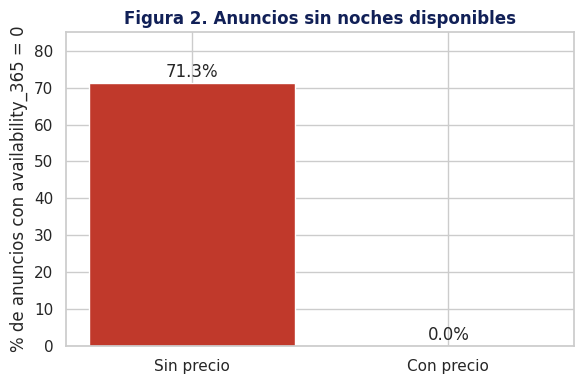

In [9]:
sin_precio = df["price"].isna()
disp_cero = df["availability_365"] == 0

pct_sin_precio = disp_cero[sin_precio].mean() * 100
pct_con_precio = disp_cero[~sin_precio].mean() * 100

print(f"Anuncios SIN precio con availability_365 = 0: {disp_cero[sin_precio].sum():,} de {sin_precio.sum():,} ({pct_sin_precio:.1f}%)")
print(f"Anuncios CON precio con availability_365 = 0: {disp_cero[~sin_precio].sum():,} de {(~sin_precio).sum():,} ({pct_con_precio:.2f}%)")
print("Mediana de availability_365 sin precio:", df.loc[sin_precio, "availability_365"].median())
print("Mediana de availability_365 con precio:", df.loc[~sin_precio, "availability_365"].median())

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Sin precio", "Con precio"], [pct_sin_precio, pct_con_precio], color=[ROJO, AZUL])
for i, v in enumerate([pct_sin_precio, pct_con_precio]):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center")
ax.set_ylim(0, 85)
ax.set_ylabel("% de anuncios con availability_365 = 0")
ax.set_title("Figura 2. Anuncios sin noches disponibles")
plt.tight_layout()
plt.show()

**Figura 2.** Los 1,793 anuncios sin precio no son un faltante aleatorio: el 71.3% (1,279) tiene `availability_365` igual a cero, es decir, un calendario sin noches disponibles. Entre los anuncios que sí tienen precio ese caso es casi inexistente (0.05%, 14 de 29,637). La mediana de disponibilidad es 0 días en el primer grupo y 309 en el segundo.

Esto sugiere que muchos anuncios sin precio están inactivos o con el calendario bloqueado al momento de la captura. Implica que imputar el precio con una mediana inventaría un dato para anuncios que quizá ni están a la venta.

### Registros duplicados

In [10]:
print("Duplicados exactos (todas las columnas):", df.duplicated().sum())
print("id repetidos:", df["id"].duplicated().sum())

cols_sin_id = [c for c in df.columns if c != "id"]
print("Registros idénticos en todo menos el id:", df.duplicated(subset=cols_sin_id).sum())
print("Anuncios con el mismo anfitrión y las mismas coordenadas que otro:",
      df.duplicated(subset=["host_id", "latitude", "longitude"]).sum())

casi_dup = df[df.duplicated(subset=cols_sin_id, keep=False)].sort_values(cols_sin_id)
print("Filas involucradas en los casi-duplicados:", len(casi_dup))
casi_dup[["id", "name", "host_id", "room_type", "price", "number_of_reviews", "calculated_host_listings_count"]].head(8)

Duplicados exactos (todas las columnas): 0
id repetidos: 0
Registros idénticos en todo menos el id: 10
Anuncios con el mismo anfitrión y las mismas coordenadas que otro: 3469
Filas involucradas en los casi-duplicados: 19


,id,name,host_id,room_type,price,number_of_reviews,calculated_host_listings_count
7200,1184051752569881475,Acogedora Habitación,202714576,Private room,559.0,0,3
12892,1184081138530862070,Acogedora Habitación,202714576,Private room,559.0,0,3
4560,1695085953252550385,Alojamiento Jardin Balbuena cerca GNP AICM Zócalo,1681361866873395570,Private room,760.0,0,11
24680,1692348006405790644,Alojamiento Jardin Balbuena cerca GNP AICM Zócalo,1681361866873395570,Private room,760.0,0,11
24678,1692335493160385300,Alojamiento Jardin Balbuena cerca GNP AICM Zócalo,1681361866873395570,Private room,808.0,0,11
24804,1692323170931174927,Alojamiento Jardin Balbuena cerca GNP AICM Zócalo,1681361866873395570,Private room,808.0,0,11
14930,1706541345913168399,"Blueground | Roma Sur, view, nr Parque México",498701635,Entire home/apt,1770.0,0,104
15363,1693626752372834423,"Blueground | Roma Sur, view, nr Parque México",498701635,Entire home/apt,1770.0,0,104


No hay duplicados exactos ni `id` repetidos. Al ignorar el `id` aparecen 10 registros que repiten todos sus atributos (19 filas involucradas). Todos tienen cero reseñas y pertenecen a anfitriones con varios anuncios (entre 3 y 104), por lo que lo más probable es que sean unidades idénticas de un mismo edificio u hotel, cada una con su propio anuncio. Por eso no se eliminan, tienen `id` distintos y representan oferta real.

Además, 3,469 anuncios comparten anfitrión y coordenadas con otro. Esto también se explica por edificios con varias unidades y no es un error.

### Valores imposibles o fuera de rango

In [11]:
reglas = {
    "price <= 0": (df["price"] <= 0).sum(),
    "price < 100 MXN": (df["price"] < 100).sum(),
    "price > 50,000 MXN": (df["price"] > 50000).sum(),
    "price > 100,000 MXN": (df["price"] > 100000).sum(),
    "minimum_nights > 365": (df["minimum_nights"] > 365).sum(),
    "reviews_per_month > 31 (más de una reseña al día)": (df["reviews_per_month"] > 31).sum(),
    "number_of_reviews_ltm > number_of_reviews": (df["number_of_reviews_ltm"] > df["number_of_reviews"]).sum(),
    "availability_365 fuera de [0, 365]": (~df["availability_365"].between(0, 365)).sum(),
    "coordenadas fuera de la CDMX (caja aproximada)": (~(df["latitude"].between(19.0, 19.6) & df["longitude"].between(-99.4, -98.9))).sum(),
}
pd.Series(reglas, name="registros").to_frame()

,registros
price <= 0,0
price < 100 MXN,11
"price > 50,000 MXN",79
"price > 100,000 MXN",39
minimum_nights > 365,5
reviews_per_month > 31 (más de una reseña al día),16
number_of_reviews_ltm > number_of_reviews,0
"availability_365 fuera de [0, 365]",0
coordenadas fuera de la CDMX (caja aproximada),0


Ningún registro viola reglas estructurales: no hay precios menores o iguales a cero, disponibilidad fuera de 0 a 365, coordenadas fuera de la ciudad ni anuncios con más reseñas en los últimos 12 meses que en total.

Los problemas son de valores extremos:

- 79 anuncios cuestan más de 50,000 MXN por noche, 39 de ellos más de 100,000. El máximo es 1,141,520 MXN en un cuarto privado, que probablemente sea un error de captura.
- 11 anuncios cuestan menos de 100 MXN por noche.
- 5 anuncios exigen más de 365 noches mínimas.
- 16 anuncios tienen más de 31 reseñas por mes (máximo 121.89), es decir, más de una reseña al día. Para un solo alojamiento es poco creíble, y apunta a propiedades con varias unidades agrupadas en un mismo anuncio.

### Cardinalidad de los atributos categóricos

In [12]:
cat_analisis = ["neighbourhood", "room_type", "host_name", "name", "last_review"]
cardinalidad = pd.DataFrame({
    "únicos": df[cat_analisis].nunique(),
    "más frecuente": [df[c].mode()[0] for c in cat_analisis],
    "% del más frecuente": [round(df[c].value_counts(normalize=True).iloc[0] * 100, 1) for c in cat_analisis],
})
cardinalidad

,únicos,más frecuente,% del más frecuente
neighbourhood,16,Cuauhtémoc,46.0
room_type,4,Entire home/apt,66.8
host_name,5040,Alejandro,1.1
name,29847,Perfecto Loft en gran ubicación,0.2
last_review,1702,2026-05-31,5.8


`room_type` (4 categorías) y `neighbourhood` (16 alcaldías, es decir, todas las de la ciudad) tienen baja cardinalidad y son utilizables directamente como categóricos. En cambio `name`, `host_name` y `last_review` tienen cardinalidad alta: `name` es texto libre (29,847 títulos distintos en 31,430 anuncios), `host_name` tiene 5,040 nombres distintos y ninguno supera 1.1% de los registros, y `last_review` es una fecha guardada como texto. Ninguno sirve como categoría.

## Análisis univariado

Se analizan los atributos más relevantes para el problema. La variable objetivo candidata es `price`. Junto a ella se revisan las variables numéricas que describen las reglas del anuncio (`minimum_nights`, `availability_365`), su actividad (`number_of_reviews`, `reviews_per_month`) y la escala del anfitrión (`calculated_host_listings_count`). Entre los categóricos se revisan `room_type` y `neighbourhood`. Se omiten los identificadores y el texto libre.

In [13]:
num_uni = ["price", "minimum_nights", "availability_365", "number_of_reviews",
           "reviews_per_month", "calculated_host_listings_count"]

resumen = df[num_uni].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).T
resumen["asimetría"] = df[num_uni].skew()
resumen.round(2)

,count,mean,std,min,25%,50%,75%,90%,99%,max,asimetría
price,29637.0,2913.74,9398.89,19.00,1073.00,1756.00,2853.00,4964.40,20292.68,1141520.00,65.93
minimum_nights,31419.0,2.90,16.08,1.00,1.00,1.00,2.00,3.00,30.00,729.00,22.98
availability_365,31430.0,250.38,117.88,0.00,166.00,299.00,353.00,364.00,365.00,365.00,-0.78
number_of_reviews,31430.0,54.72,90.94,0.00,2.00,18.00,69.00,154.00,430.42,1739.00,3.81
reviews_per_month,25931.0,2.01,2.34,0.01,0.57,1.45,2.79,4.31,9.37,121.89,9.44
calculated_host_listings_count,31430.0,13.95,29.20,1.00,1.00,3.00,11.00,36.00,186.00,189.00,3.91


La tabla confirma que casi todas las variables numéricas tienen una media muy distinta de su mediana, señal de colas largas a la derecha. En el precio, la media (2,914 MXN) es 66% mayor que la mediana (1,756 MXN). Por eso se usarán medianas y escalas logarítmicas para resumir y comparar.

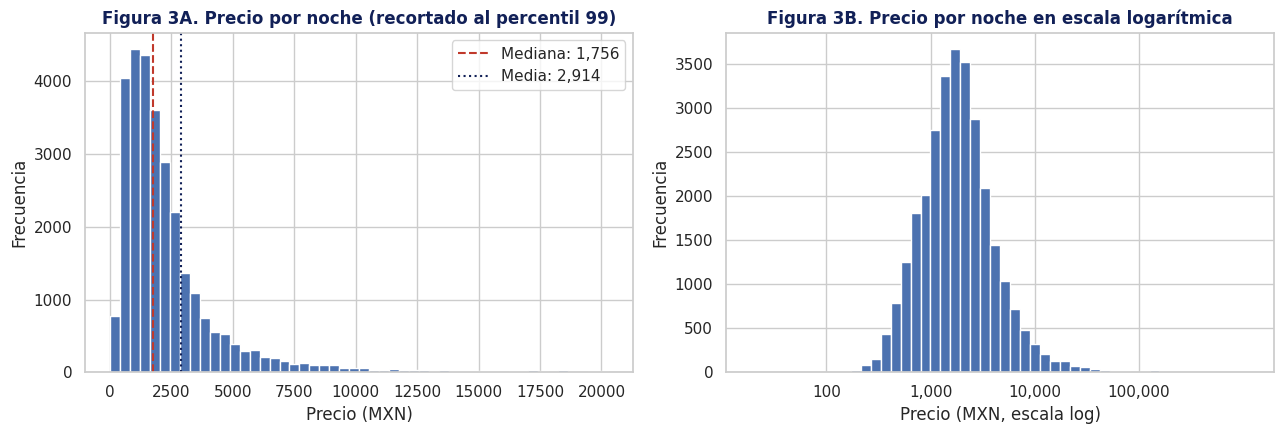

Asimetría del precio: 65.9 | del log10(precio): 0.64
Percentil 99: 20,293 | máximo: 1,141,520


In [14]:
precio = df["price"].dropna()
tope = precio.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(precio[precio <= tope], bins=50, color=AZUL, edgecolor="white")
axes[0].axvline(precio.median(), color=ROJO, ls="--", label=f"Mediana: {precio.median():,.0f}")
axes[0].axvline(precio.mean(), color=AZUL_OSCURO, ls=":", label=f"Media: {precio.mean():,.0f}")
axes[0].set_title("Figura 3A. Precio por noche (recortado al percentil 99)")
axes[0].set_xlabel("Precio (MXN)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

axes[1].hist(np.log10(precio), bins=50, color=AZUL, edgecolor="white")
axes[1].set_xticks([2, 3, 4, 5])
axes[1].set_xticklabels(["100", "1,000", "10,000", "100,000"])
axes[1].set_title("Figura 3B. Precio por noche en escala logarítmica")
axes[1].set_xlabel("Precio (MXN, escala log)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print(f"Asimetría del precio: {precio.skew():.1f} | del log10(precio): {np.log10(precio).skew():.2f}")
print(f"Percentil 99: {tope:,.0f} | máximo: {precio.max():,.0f}")

**Figura 3.** El precio por noche está extremadamente sesgado a la derecha (asimetría 65.9). La mediana es 1,756 MXN, la mitad central de los anuncios cuesta entre 1,073 y 2,853 MXN, el percentil 99 llega a 20,293 y el máximo es 1,141,520. En escala lineal (panel A) la distribución se aplasta contra la izquierda aun después de recortar al percentil 99. En escala logarítmica (panel B) es unimodal y casi simétrica (asimetría 0.64), centrada cerca de 10^3.2, es decir, unos 1,760 MXN.

Implica que, al comparar o modelar precios, conviene trabajar con el logaritmo y reportar medianas, porque unos cuantos anuncios muy caros dominan la media.

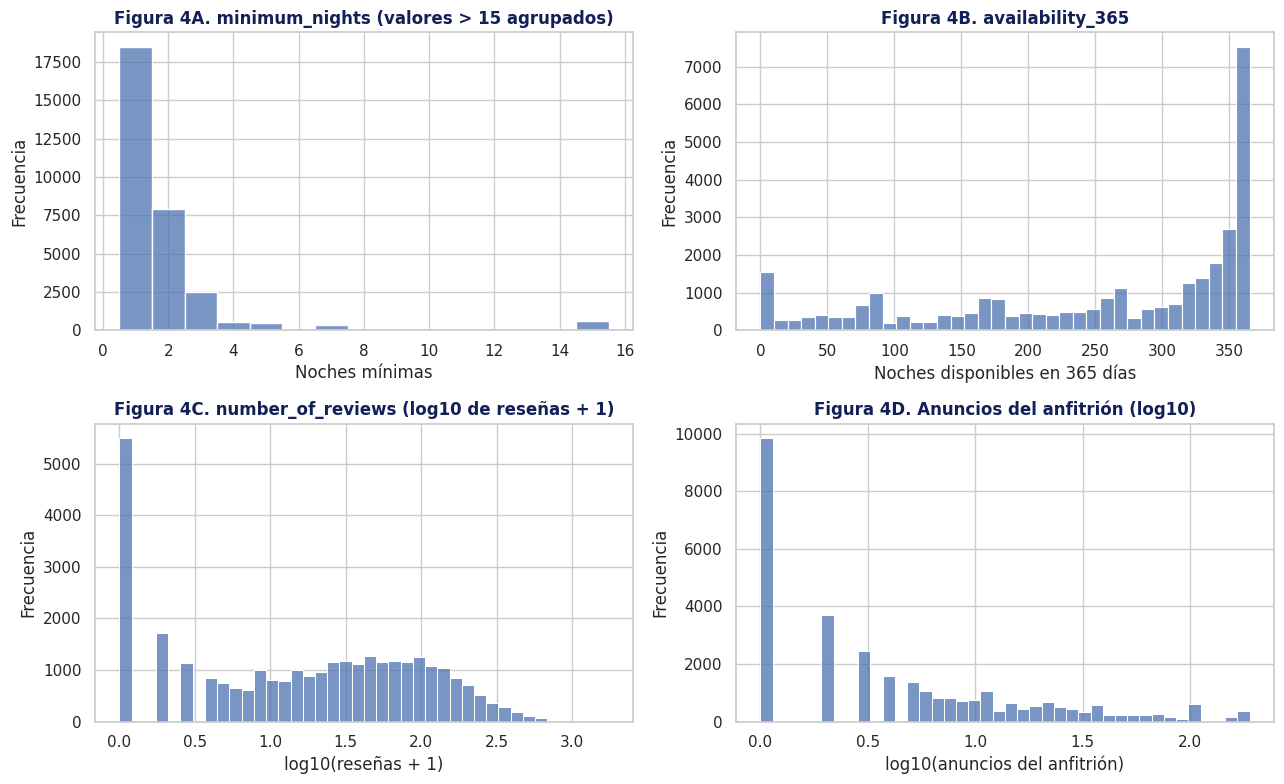

minimum_nights = 1: 58.9% | <= 3: 92.2% | >= 28: 1.3%
availability_365 >= 300: 50.0% | = 365: 7.9% | = 0: 4.1%
Sin reseñas: 17.5% | con 100 o más: 17.9%
Anfitriones de un solo anuncio: 31.3% | con 5 o más anuncios: 43.9%


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df["minimum_nights"].clip(upper=15), discrete=True, color=AZUL, ax=axes[0, 0])
axes[0, 0].set_title("Figura 4A. minimum_nights (valores > 15 agrupados)")
axes[0, 0].set_xlabel("Noches mínimas")

sns.histplot(df["availability_365"], bins=36, color=AZUL, ax=axes[0, 1])
axes[0, 1].set_title("Figura 4B. availability_365")
axes[0, 1].set_xlabel("Noches disponibles en 365 días")

sns.histplot(np.log10(df["number_of_reviews"] + 1), bins=40, color=AZUL, ax=axes[1, 0])
axes[1, 0].set_title("Figura 4C. number_of_reviews (log10 de reseñas + 1)")
axes[1, 0].set_xlabel("log10(reseñas + 1)")

sns.histplot(np.log10(df["calculated_host_listings_count"]), bins=40, color=AZUL, ax=axes[1, 1])
axes[1, 1].set_title("Figura 4D. Anuncios del anfitrión (log10)")
axes[1, 1].set_xlabel("log10(anuncios del anfitrión)")

for ax in axes.flat:
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print(f"minimum_nights = 1: {(df['minimum_nights'] == 1).mean():.1%} | <= 3: {(df['minimum_nights'] <= 3).mean():.1%} | >= 28: {(df['minimum_nights'] >= 28).mean():.1%}")
print(f"availability_365 >= 300: {(df['availability_365'] >= 300).mean():.1%} | = 365: {(df['availability_365'] == 365).mean():.1%} | = 0: {(df['availability_365'] == 0).mean():.1%}")
print(f"Sin reseñas: {(df['number_of_reviews'] == 0).mean():.1%} | con 100 o más: {(df['number_of_reviews'] >= 100).mean():.1%}")
print(f"Anfitriones de un solo anuncio: {(df['calculated_host_listings_count'] == 1).mean():.1%} | con 5 o más anuncios: {(df['calculated_host_listings_count'] >= 5).mean():.1%}")

**Figura 4.** Cada panel muestra un aspecto distinto del mercado:

- **A. `minimum_nights`:** 58.9% de los anuncios exige solo una noche y 92.2% pide tres o menos. Solo 1.3% exige 28 noches o más. Es un mercado de estancias cortas, con unos pocos casos de renta larga (el máximo es 729 noches).
- **B. `availability_365`:** la mediana es 299 días y la mitad de los anuncios tiene 300 o más. Hay 7.9% con el calendario completamente abierto (365) y 4.1% (1,293 anuncios) con cero noches. La mayoría de la oferta está abierta casi todo el año.
- **C. `number_of_reviews`:** 17.5% de los anuncios no tiene ninguna reseña, la mediana es 18 y 17.9% tiene 100 o más (máximo 1,739). La escala logarítmica muestra una distribución muy asimétrica, con un grupo grande de anuncios nuevos o poco usados y otro de anuncios muy establecidos.
- **D. Anuncios del anfitrión:** el 31.3% de los anuncios pertenece a anfitriones con un solo anuncio, pero la mediana es 3, el percentil 90 llega a 36 y el máximo es 189. Hay una cola larga de anfitriones que operan como negocio, y el 43.9% de los anuncios pertenece a anfitriones con cinco o más.

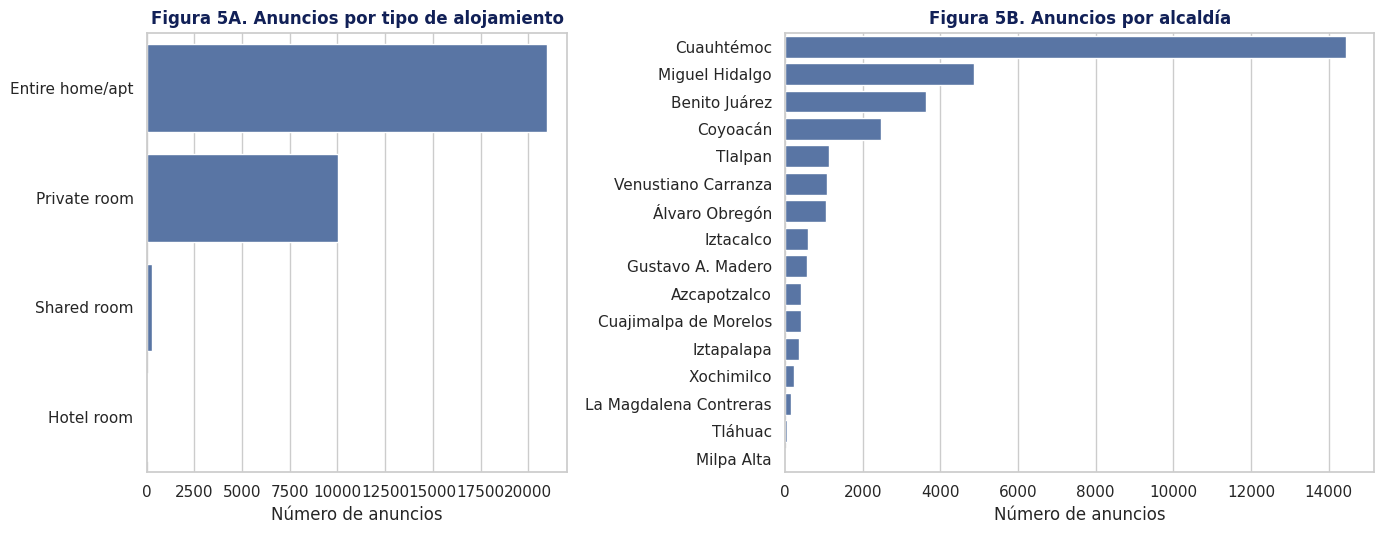

room_type
Entire home/apt    66.8
Private room       32.0
Shared room         1.0
Hotel room          0.3

neighbourhood
Cuauhtémoc        46.0
Miguel Hidalgo    15.5
Benito Juárez     11.5


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1, 1.4]})

orden_tipo = df["room_type"].value_counts().index
sns.countplot(data=df, y="room_type", order=orden_tipo, color=AZUL, ax=axes[0])
axes[0].set_title("Figura 5A. Anuncios por tipo de alojamiento")
axes[0].set_xlabel("Número de anuncios")
axes[0].set_ylabel("")

orden_alc = df["neighbourhood"].value_counts().index
sns.countplot(data=df, y="neighbourhood", order=orden_alc, color=AZUL, ax=axes[1])
axes[1].set_title("Figura 5B. Anuncios por alcaldía")
axes[1].set_xlabel("Número de anuncios")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(df["room_type"].value_counts(normalize=True).mul(100).round(1).to_string())
print()
print(df["neighbourhood"].value_counts(normalize=True).mul(100).round(1).head(3).to_string())

**Figura 5.** El 66.8% de los anuncios (21,000) son casas o departamentos completos y 32.0% (10,043) son cuartos privados. Los cuartos compartidos (301, 1.0%) y de hotel (86, 0.3%) son casi marginales.

Por alcaldía, la concentración es muy fuerte: Cuauhtémoc tiene 46.0% de los anuncios (14,449), Miguel Hidalgo 15.5% y Benito Juárez 11.5%. Entre las tres suman 73.0%. En el otro extremo, Milpa Alta (26) y Tláhuac (49) casi no tienen oferta.

Implica que los grupos están muy desbalanceados. Cualquier comparación que incluya los cuartos de hotel o compartidos, o las alcaldías pequeñas, descansa en muy pocos casos y es poco confiable.

## Análisis bivariado

Como `price` es la variable objetivo candidata, se exploran sus relaciones con tres atributos que, por conocimiento del dominio, deberían influir. Cada uno responde una pregunta distinta:

1. **Tipo de alojamiento (`room_type`):** no cuesta lo mismo rentar una casa completa que un cuarto compartido. Es el factor más obvio y sirve para comprobar que los datos tienen sentido.
2. **Alcaldía (`neighbourhood`):** la ubicación es el otro factor clásico del precio de un alojamiento.
3. **Tamaño del anfitrión (`calculated_host_listings_count`):** la hipótesis es que los anfitriones con muchos anuncios operan como negocio. Se compara si cobran distinto y si mantienen más noches disponibles.

Como el precio es muy sesgado, se usan diagramas de caja con **escala logarítmica** y se comparan medianas.

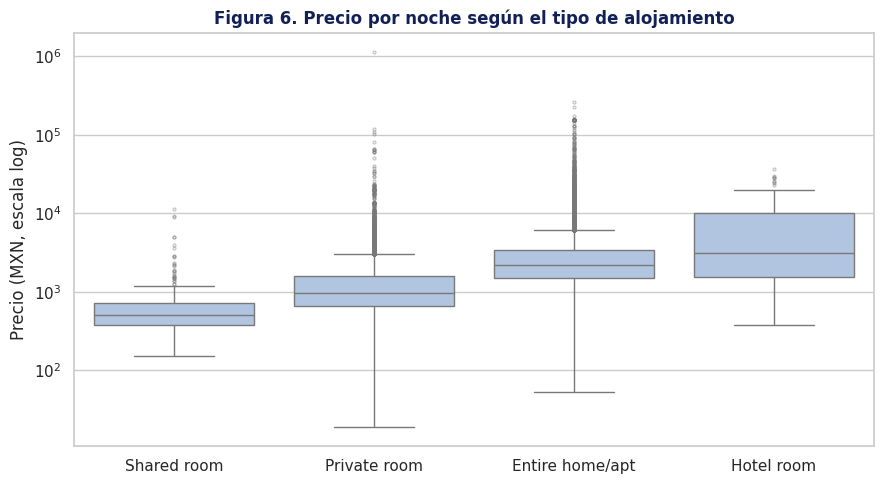

,count,median,mean
room_type,,,
Shared room,291,503.0,765.0
Private room,9407,970.0,1759.0
Entire home/apt,19856,2163.0,3473.0
Hotel room,83,3132.0,7595.0


In [17]:
orden_tipo = df.groupby("room_type")["price"].median().sort_values().index

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="room_type", y="price", order=orden_tipo, color=AZUL_CLARO,
            flierprops={"markersize": 2, "alpha": 0.4}, ax=ax)
ax.set_yscale("log")
ax.set_title("Figura 6. Precio por noche según el tipo de alojamiento")
ax.set_xlabel("")
ax.set_ylabel("Precio (MXN, escala log)")
plt.tight_layout()
plt.show()

df.groupby("room_type")["price"].agg(["count", "median", "mean"]).loc[orden_tipo].round(0)

**Figura 6.** El orden de las medianas es el esperado: cuarto compartido 503 MXN, cuarto privado 970, casa o departamento completo 2,163 y cuarto de hotel 3,132. El alojamiento completo cuesta 2.2 veces la mediana de un cuarto privado. Sin embargo, las cajas se traslapan y hay cuartos privados más caros que muchos alojamientos completos (incluido el extremo de 1,141,520 MXN), por lo que el tipo ordena los precios pero no los determina. La mediana de hotel se basa en solo 83 anuncios con precio.

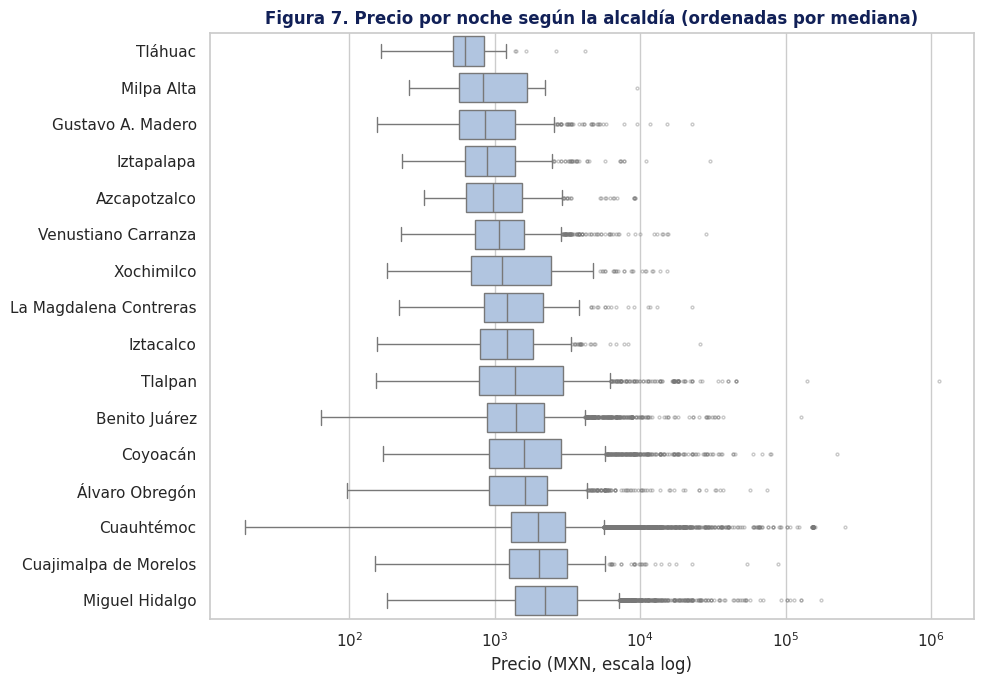

,count,median
neighbourhood,,
Tláhuac,49,628.0
Milpa Alta,25,824.0
Gustavo A. Madero,531,856.0
Iztapalapa,356,881.0
Azcapotzalco,399,970.0
Venustiano Carranza,1022,1070.0
Xochimilco,213,1130.0
La Magdalena Contreras,135,1206.0
Iztacalco,569,1222.0


In [18]:
orden_alc = df.groupby("neighbourhood")["price"].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 7))
sns.boxplot(data=df, y="neighbourhood", x="price", order=orden_alc, color=AZUL_CLARO,
            flierprops={"markersize": 2, "alpha": 0.4}, ax=ax)
ax.set_xscale("log")
ax.set_title("Figura 7. Precio por noche según la alcaldía (ordenadas por mediana)")
ax.set_xlabel("Precio (MXN, escala log)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

df.groupby("neighbourhood")["price"].agg(["count", "median"]).loc[orden_alc].round(0)

**Figura 7.** Las alcaldías del centro y el poniente tienen los precios más altos: Miguel Hidalgo (mediana 2,212 MXN), Cuajimalpa de Morelos (2,014) y Cuauhtémoc (1,979). Las más baratas son periféricas: Tláhuac (628), Milpa Alta (824), Gustavo A. Madero (856) e Iztapalapa (881). La mediana de la alcaldía más cara es 3.5 veces la de la más barata.

Hay dos matices. Tláhuac (49 anuncios) y Milpa Alta (25 con precio) tienen muy pocos casos, así que sus medianas son poco estables. Y dentro de cada alcaldía la dispersión es grande, por lo que la alcaldía separa grupos de precio, pero no los determina.

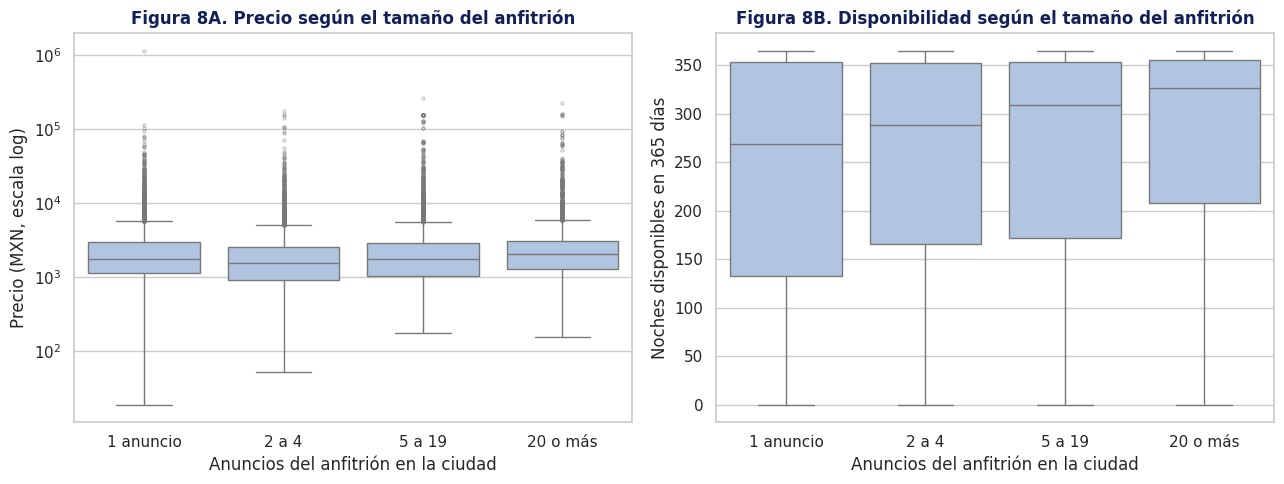

,anuncios,precio_mediana,disponibilidad_mediana,% de anuncios
grupo_host,,,,
1 anuncio,9853,1775.0,269.0,31.3
2 a 4,7772,1558.0,288.0,24.7
5 a 19,8488,1725.0,309.0,27.0
20 o más,5317,2031.0,326.0,16.9


In [19]:
datos = df.assign(grupo_host=pd.cut(df["calculated_host_listings_count"],
                                    bins=[0, 1, 4, 19, np.inf],
                                    labels=["1 anuncio", "2 a 4", "5 a 19", "20 o más"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=datos, x="grupo_host", y="price", color=AZUL_CLARO,
            flierprops={"markersize": 2, "alpha": 0.4}, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Figura 8A. Precio según el tamaño del anfitrión")
axes[0].set_xlabel("Anuncios del anfitrión en la ciudad")
axes[0].set_ylabel("Precio (MXN, escala log)")

sns.boxplot(data=datos, x="grupo_host", y="availability_365", color=AZUL_CLARO, ax=axes[1])
axes[1].set_title("Figura 8B. Disponibilidad según el tamaño del anfitrión")
axes[1].set_xlabel("Anuncios del anfitrión en la ciudad")
axes[1].set_ylabel("Noches disponibles en 365 días")

plt.tight_layout()
plt.show()

tabla_host = datos.groupby("grupo_host", observed=True).agg(
    anuncios=("id", "count"),
    precio_mediana=("price", "median"),
    disponibilidad_mediana=("availability_365", "median"),
)
tabla_host["% de anuncios"] = (tabla_host["anuncios"] / len(datos) * 100).round(1)
tabla_host

**Figura 8.** El precio cambia poco con el tamaño del anfitrión: las medianas son 1,775 MXN (un anuncio), 1,558 (de 2 a 4), 1,725 (de 5 a 19) y 2,031 (20 o más). Solo los anfitriones más grandes, que concentran 16.9% de los anuncios, cobran algo más.

La disponibilidad sí sube de forma consistente: la mediana pasa de 269 a 288, 309 y 326 noches al crecer el tamaño del anfitrión. Los anfitriones con muchos anuncios mantienen su calendario abierto casi todo el año, un patrón propio de una operación profesional. Entre los de 5 a 19 anuncios (27.0%) y los de 20 o más (16.9%) controlan 43.9% de la oferta.

## Vista multivariada

Primero se revisa si existe relación monótona entre las variables numéricas con una matriz de correlación. Se usa Spearman en lugar de Pearson porque casi todas las variables tienen distribuciones muy sesgadas y valores extremos, que distorsionan la correlación de Pearson.

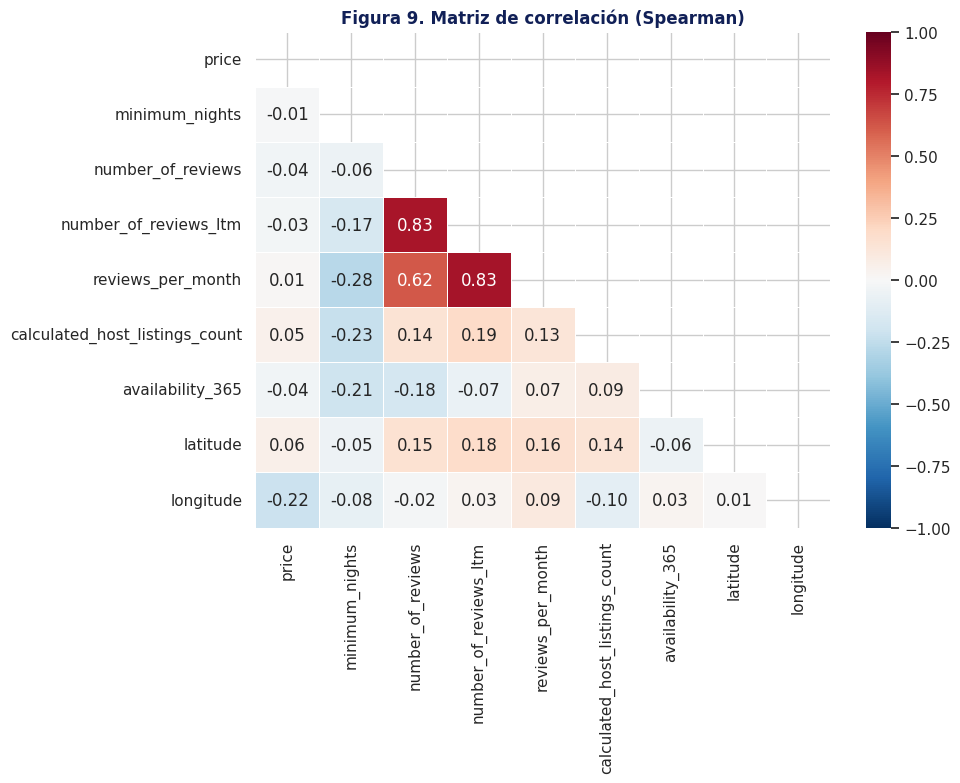

In [20]:
vars_corr = ["price", "minimum_nights", "number_of_reviews", "number_of_reviews_ltm",
             "reviews_per_month", "calculated_host_listings_count", "availability_365",
             "latitude", "longitude"]

corr = df[vars_corr].corr(method="spearman")
mascara = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mascara, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Figura 9. Matriz de correlación (Spearman)")
plt.tight_layout()
plt.show()

**Figura 9.** Hay dos lecturas principales.

**Las variables de actividad son redundantes.** `number_of_reviews` y `number_of_reviews_ltm` correlacionan 0.83, igual que `reviews_per_month` con `number_of_reviews_ltm`, y `number_of_reviews` con `reviews_per_month` 0.62. Las tres miden casi lo mismo (qué tanto se usa el anuncio) y no conviene usarlas juntas sin pensarlo. `minimum_nights` se relaciona de forma negativa con la actividad (−0.28 con `reviews_per_month`), con el número de anuncios del anfitrión (−0.23) y con la disponibilidad (−0.21): los anuncios que exigen estancias largas rotan menos huéspedes.

**El precio casi no se relaciona con ninguna variable numérica.** Salvo la longitud (−0.22), todas sus correlaciones están entre −0.04 y 0.06. Las relaciones del precio con el tipo de alojamiento y la alcaldía (Figuras 6 y 7) no aparecen aquí porque esas variables son categóricas. Esto sugiere que el precio depende sobre todo de qué se renta y dónde, y no de qué tan activo es el anuncio.

Como la longitud es la única coordenada relacionada con el precio, se grafica el color como tercera dimensión: cada anuncio es un punto en (longitud, latitud) y el color representa su precio en escala logarítmica.

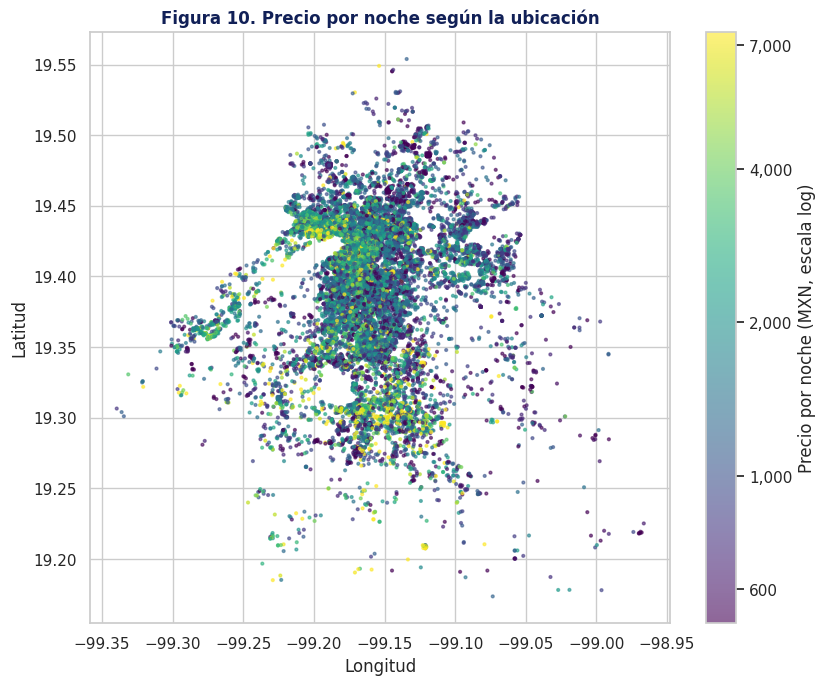

Mediana por tercil de longitud: {'oeste': 1964.0, 'centro': 1998.0, 'este': 1376.0}
Mediana por tercil de latitud:  {'sur': 1450.0, 'centro': 2084.0, 'norte': 1749.0}


In [21]:
datos_mapa = df.dropna(subset=["price"]).sample(frac=1, random_state=42)  # orden aleatorio para que ningún precio quede siempre encima
log_precio = np.log10(datos_mapa["price"])
vmin, vmax = np.log10(datos_mapa["price"].quantile([0.05, 0.95]))

fig, ax = plt.subplots(figsize=(8.5, 7))
puntos = ax.scatter(datos_mapa["longitude"], datos_mapa["latitude"], c=log_precio,
                    cmap="viridis", s=4, alpha=0.6, vmin=vmin, vmax=vmax)
barra = plt.colorbar(puntos, ax=ax)
marcas = [600, 1000, 2000, 4000, 7000]
barra.set_ticks(np.log10(marcas))
barra.set_ticklabels([f"{m:,}" for m in marcas])
barra.set_label("Precio por noche (MXN, escala log)")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Figura 10. Precio por noche según la ubicación")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

por_long = datos_mapa.groupby(pd.qcut(datos_mapa["longitude"], 3, labels=["oeste", "centro", "este"]), observed=True)["price"].median()
por_lat = datos_mapa.groupby(pd.qcut(datos_mapa["latitude"], 3, labels=["sur", "centro", "norte"]), observed=True)["price"].median()
print("Mediana por tercil de longitud:", por_long.round(0).to_dict())
print("Mediana por tercil de latitud: ", por_lat.round(0).to_dict())

**Figura 10.** El mapa de puntos reproduce la forma de la ciudad sin necesidad de un mapa base, y muestra que el precio tiene un patrón geográfico. Los puntos amarillos (precios altos) se agrupan en el centro y el poniente, y el oriente se ve más oscuro (más barato). Por terciles, la mediana es 1,964 MXN en el tercio más al oeste, 1,998 en el centro y 1,376 en el este. Por latitud es 1,450 en el sur, 2,084 en el centro y 1,749 en el norte.

Esto explica por qué la longitud es la única coordenada con correlación apreciable con el precio (−0.22), y sugiere que la ubicación explica parte del precio y que la alcaldía es una forma gruesa de capturarla. La concentración de puntos en el centro también recuerda el dominio de Cuauhtémoc en la oferta. Como hay muchos puntos encimados, la lectura visual es aproximada y se apoya en las medianas por terciles.

## Procesamiento 1: limpieza de datos

### Justificación de la técnica

De los tipos de procesamiento posibles, se aplican dos: limpieza de datos y reducción de dimensionalidad.

- El dataset llegó con problemas concretos y documentados: dos columnas vacías, un identificador mal tipado, faltantes en el precio, faltantes estructurales en las reseñas y valores extremos en el precio y en las reseñas por mes.
- Es real: se trata de una captura de datos públicos, no de un conjunto preparado, así que la limpieza es necesaria antes de cualquier análisis posterior. Por ejemplo, un modelo de precios aprendería de errores de captura como el anuncio de 1,141,520 MXN.
- Es el paso previo para las demás técnicas: aplicar el PCA con anuncios sin precio, valores imposibles o columnas vacías daría resultados poco confiables.

Se trabaja sobre una copia (`df_limpio`) y se deja `df` sin modificar para poder comparar antes y después.

### Plan de limpieza

| Problema detectado | Decisión | Justificación |
|---|---|---|
| `neighbourhood_group` y `license` 100% vacías | Eliminar las columnas | No aportan información |
| `host_profile_id` pierde exactitud como `float64`; `host_name` es un nombre personal | Eliminar ambas columnas | Son identificadores sin valor analítico, y `host_id` ya identifica al anfitrión |
| `price` faltante (1,793 anuncios, mayoría con 0 noches disponibles) | Eliminar esas filas | Es la variable objetivo candidata. Imputarla inventaría datos para anuncios probablemente inactivos |
| Precios extremos | Eliminar los que salen de 3 veces el IQR en escala logarítmica | Conserva los anuncios caros reales y quita solo los casos casi seguramente erróneos |
| `reviews_per_month` > 31 (16 anuncios) | Eliminar esas filas | Más de una reseña diaria no es posible para un solo alojamiento |
| `reviews_per_month` vacío en anuncios sin reseñas | Rellenar con 0 | El faltante es estructural: sin reseñas, la tasa mensual es cero |
| `minimum_nights` con 11 faltantes | Rellenar con la mediana | Pocos casos y distribución muy sesgada (mediana 1) |
| `last_review` como texto | Convertir a fecha | Es una fecha; los vacíos (sin reseñas) se conservan como `NaT` |

In [22]:
def limites_iqr_log(serie, k=3):
    """Límites inferior y superior de la regla del IQR aplicada sobre log10 de la serie."""
    logs = np.log10(serie)
    q1, q3 = logs.quantile([0.25, 0.75])
    iqr = q3 - q1
    return 10 ** (q1 - k * iqr), 10 ** (q3 + k * iqr)

df_limpio = df.copy()
print("Punto de partida:", df_limpio.shape)

Punto de partida: (31430, 19)


#### Paso 1. Eliminar columnas sin valor analítico

In [23]:
columnas_fuera = ["neighbourhood_group", "license", "host_profile_id", "host_name"]
df_limpio = df_limpio.drop(columns=columnas_fuera)
print("Columnas:", df.shape[1], "->", df_limpio.shape[1])

Columnas: 19 -> 15


#### Paso 2. Eliminar anuncios sin precio

In [24]:
n_antes = len(df_limpio)
df_limpio = df_limpio.dropna(subset=["price"]).copy()
print(f"Filas eliminadas por precio faltante: {n_antes - len(df_limpio):,}")
print("Filas restantes:", f"{len(df_limpio):,}")

Filas eliminadas por precio faltante: 1,793
Filas restantes: 29,637


#### Paso 3. Eliminar precios extremos

Se aplica la regla del rango intercuartílico (IQR) sobre `log10(price)`, porque el precio es muy sesgado y en escala lineal la regla marcaría demasiados anuncios caros pero reales. Se usa un factor de **3** veces el IQR (en lugar del habitual 1.5) para quitar solo los valores extremos. Se muestra cuántos marcaría cada factor.

In [25]:
for k in (1.5, 3):
    inf, sup = limites_iqr_log(df_limpio["price"], k=k)
    marcados = ((df_limpio["price"] < inf) | (df_limpio["price"] > sup)).sum()
    print(f"Factor {k}: acepta de {inf:,.0f} a {sup:,.0f} MXN -> marca {marcados} anuncios")

inf, sup = limites_iqr_log(df_limpio["price"], k=3)
extremos = (df_limpio["price"] < inf) | (df_limpio["price"] > sup)
print(f"\nSe eliminan con factor 3: {(df_limpio['price'] < inf).sum()} por debajo de {inf:,.0f} y {(df_limpio['price'] > sup).sum()} por encima de {sup:,.0f}")

df_limpio = df_limpio[~extremos].copy()
print("Filas restantes:", f"{len(df_limpio):,}")

Factor 1.5: acepta de 247 a 12,370 MXN -> marca 720 anuncios
Factor 3: acepta de 57 a 53,630 MXN -> marca 78 anuncios

Se eliminan con factor 3: 4 por debajo de 57 y 74 por encima de 53,630
Filas restantes: 29,559


#### Paso 4. Reseñas por mes: valores imposibles y faltantes estructurales

In [26]:
imposibles = df_limpio["reviews_per_month"] > 31
print("Anuncios con más de 31 reseñas por mes (se eliminan):", imposibles.sum())
df_limpio = df_limpio[~imposibles].copy()

sin_resenas = df_limpio["number_of_reviews"] == 0
print("reviews_per_month vacío antes:", df_limpio["reviews_per_month"].isna().sum())
df_limpio.loc[sin_resenas, "reviews_per_month"] = 0
print("reviews_per_month vacío después:", df_limpio["reviews_per_month"].isna().sum())
print("Filas restantes:", f"{len(df_limpio):,}")

Anuncios con más de 31 reseñas por mes (se eliminan): 16
reviews_per_month vacío antes: 4968
reviews_per_month vacío después: 0
Filas restantes: 29,543


#### Paso 5. Estancia mínima faltante y fecha de la última reseña

In [27]:
mediana_noches = df_limpio["minimum_nights"].median()
print("minimum_nights vacío antes:", df_limpio["minimum_nights"].isna().sum(), "| mediana usada:", mediana_noches)
df_limpio["minimum_nights"] = df_limpio["minimum_nights"].fillna(mediana_noches).astype(int)

df_limpio["last_review"] = pd.to_datetime(df_limpio["last_review"])
print("last_review ahora es:", df_limpio["last_review"].dtype)
print("last_review vacío (anuncios sin reseñas):", df_limpio["last_review"].isna().sum())

df_limpio = df_limpio.reset_index(drop=True)
print("\nResultado final:", df_limpio.shape)

minimum_nights vacío antes: 11 | mediana usada: 1.0
last_review ahora es: datetime64[ns]
last_review vacío (anuncios sin reseñas): 4968

Resultado final: (29543, 15)


### Comparación antes y después

#### Valores faltantes

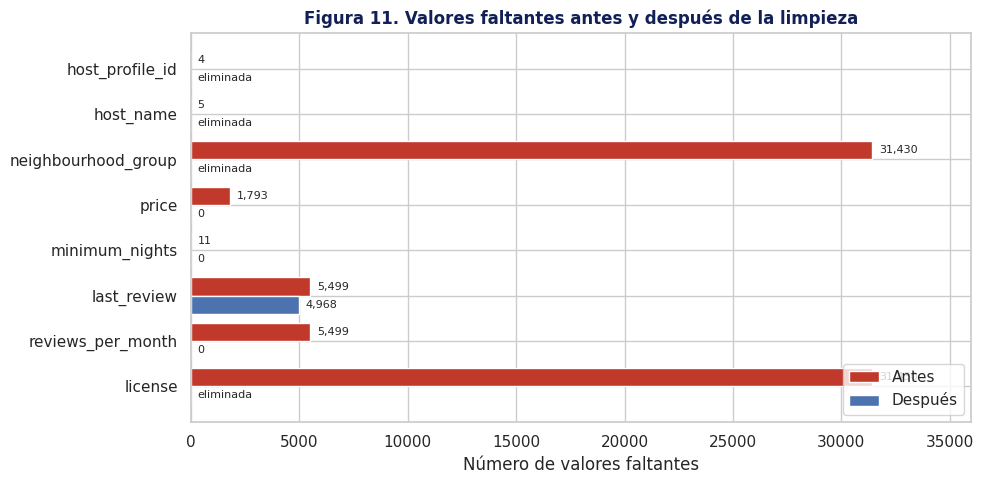

In [28]:
cols_con_faltantes = df.columns[df.isna().sum() > 0]
antes = df[cols_con_faltantes].isna().sum()
despues = df_limpio.isna().sum().reindex(cols_con_faltantes)

posiciones = np.arange(len(cols_con_faltantes))
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(posiciones - 0.2, antes.values, height=0.4, color=ROJO, label="Antes")
ax.barh(posiciones + 0.2, despues.fillna(0).values, height=0.4, color=AZUL, label="Después")
for i, col in enumerate(cols_con_faltantes):
    ax.text(antes[col] + 300, i - 0.2, f"{antes[col]:,}", va="center", fontsize=8)
    texto = "eliminada" if col not in df_limpio.columns else f"{int(despues[col]):,}"
    ax.text(despues.fillna(0)[col] + 300, i + 0.2, texto, va="center", fontsize=8)
ax.set_yticks(posiciones)
ax.set_yticklabels(cols_con_faltantes)
ax.invert_yaxis()
ax.set_xlim(0, 36000)
ax.set_xlabel("Número de valores faltantes")
ax.set_title("Figura 11. Valores faltantes antes y después de la limpieza")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Figura 11.** Antes, ocho columnas tenían faltantes, dos de ellas completamente vacías. Después, la única columna con faltantes es `last_review` (4,968 anuncios sin reseñas), y es intencional: la fecha no existe porque no hay reseñas, y rellenarla inventaría un dato. `reviews_per_month` pasó de 5,499 vacíos a cero porque ahora vale 0 donde no hay reseñas, y los faltantes de `price` y `minimum_nights` desaparecieron. Las columnas `neighbourhood_group`, `license`, `host_profile_id` y `host_name` fueron eliminadas.

#### Precio por noche

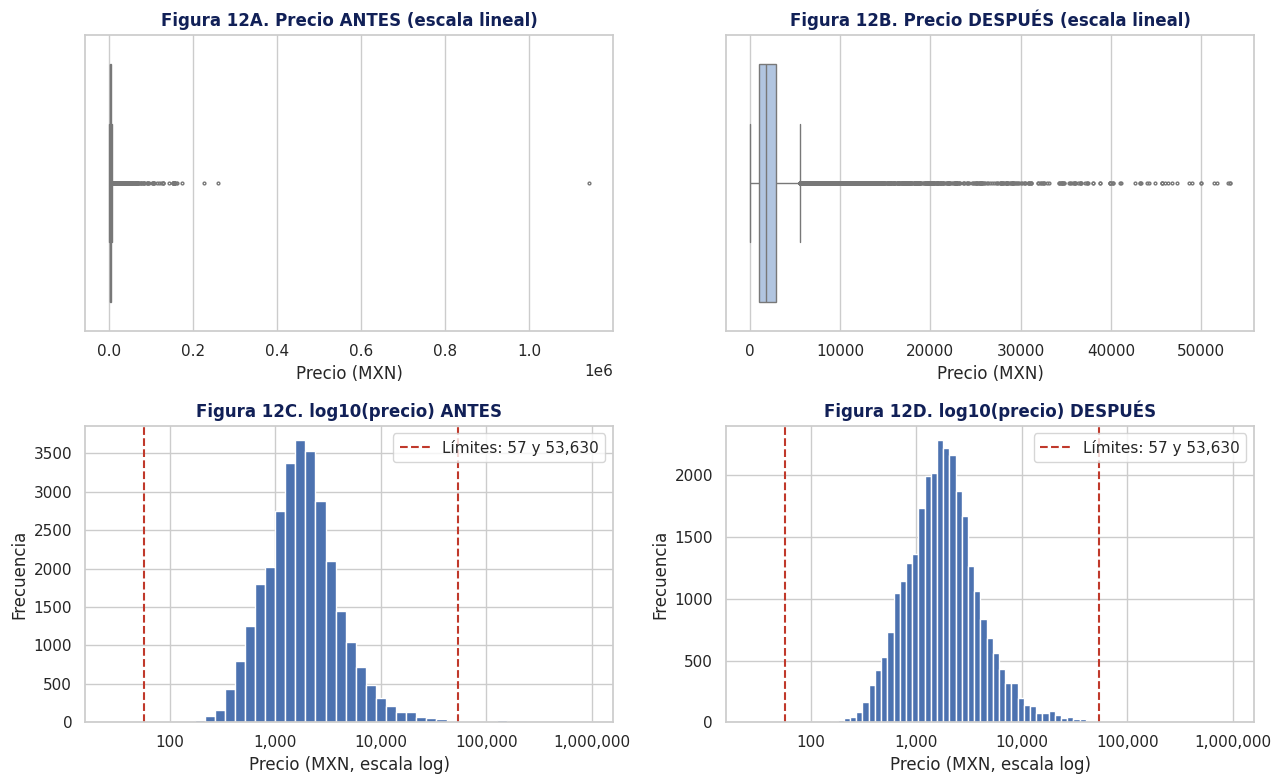

,Antes,Después
count,29637.0,29543.0
mean,2913.7,2611.7
std,9398.9,3397.1
min,19.0,61.0
25%,1073.0,1071.0
50%,1756.0,1751.0
75%,2853.0,2853.0
max,1141520.0,53150.0
asimetría,65.9,6.0


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.boxplot(x=df["price"].dropna(), color=AZUL_CLARO, flierprops={"markersize": 2}, ax=axes[0, 0])
axes[0, 0].set_title("Figura 12A. Precio ANTES (escala lineal)")
axes[0, 0].set_xlabel("Precio (MXN)")

sns.boxplot(x=df_limpio["price"], color=AZUL_CLARO, flierprops={"markersize": 2}, ax=axes[0, 1])
axes[0, 1].set_title("Figura 12B. Precio DESPUÉS (escala lineal)")
axes[0, 1].set_xlabel("Precio (MXN)")

for ax, serie, titulo in [(axes[1, 0], df["price"].dropna(), "Figura 12C. log10(precio) ANTES"),
                          (axes[1, 1], df_limpio["price"], "Figura 12D. log10(precio) DESPUÉS")]:
    ax.hist(np.log10(serie), bins=50, color=AZUL, edgecolor="white")
    ax.axvline(np.log10(inf), color=ROJO, ls="--", label=f"Límites: {inf:,.0f} y {sup:,.0f}")
    ax.axvline(np.log10(sup), color=ROJO, ls="--")
    ax.set_xlim(1.2, 6.2)
    ax.set_xticks([2, 3, 4, 5, 6])
    ax.set_xticklabels(["100", "1,000", "10,000", "100,000", "1,000,000"])
    ax.set_title(titulo)
    ax.set_xlabel("Precio (MXN, escala log)")
    ax.set_ylabel("Frecuencia")
    ax.legend()

plt.tight_layout()
plt.show()

comparacion = pd.DataFrame({"Antes": df["price"].describe(), "Después": df_limpio["price"].describe()})
comparacion.loc["asimetría"] = [df["price"].skew(), df_limpio["price"].skew()]
comparacion.round(1)

**Figura 12.** Antes de la limpieza (panel A), el diagrama de caja está comprimido: casi toda la caja queda aplastada contra la izquierda por unos pocos anuncios que llegan a 1,141,520 MXN. Después (panel B), el máximo baja a 53,150 MXN y la caja se puede leer. En escala logarítmica (paneles C y D) la forma central es la misma y solo se recortan las colas: entre las líneas rojas queda el rango que se conserva.

En números: la mediana casi no cambia (1,756 a 1,751 MXN), pero la media baja de 2,914 a 2,612 MXN, la desviación estándar cae de 9,399 a 3,397 y la asimetría pasa de 65.9 a 6.0. La limpieza quita la influencia de los errores de captura sin alterar el comportamiento típico del precio. Con el factor de 3 IQR se eliminaron 78 anuncios (0.3%) y se conservaron los que solo eran caros o baratos.

#### Reseñas por mes

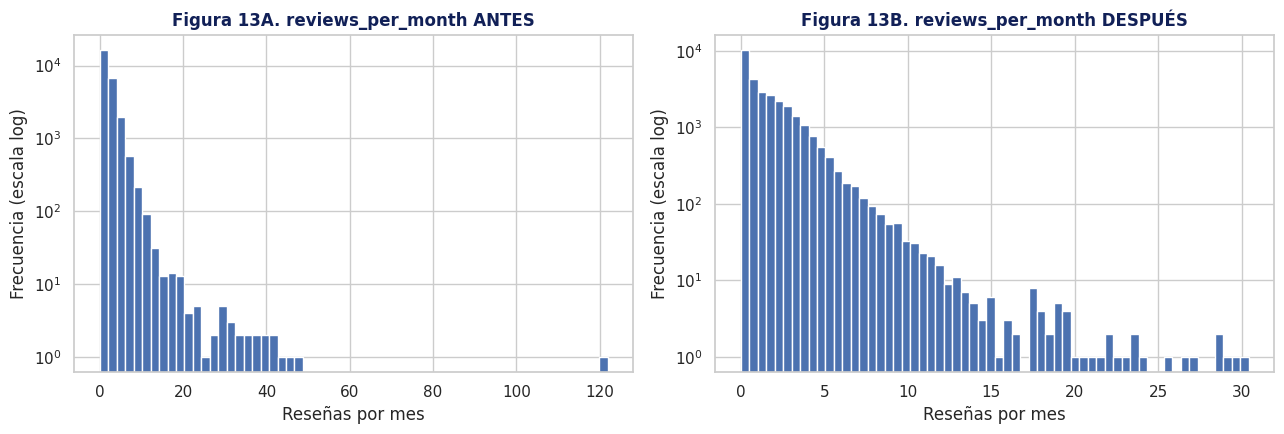

Antes:   25,931 valores | máximo 121.89 | media 2.01
Después: 29,543 valores | máximo 30.42 | media 1.70 | ceros 4,968


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["reviews_per_month"].dropna(), bins=60, color=AZUL, edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Figura 13A. reviews_per_month ANTES")
axes[0].set_xlabel("Reseñas por mes")
axes[0].set_ylabel("Frecuencia (escala log)")

axes[1].hist(df_limpio["reviews_per_month"], bins=60, color=AZUL, edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Figura 13B. reviews_per_month DESPUÉS")
axes[1].set_xlabel("Reseñas por mes")
axes[1].set_ylabel("Frecuencia (escala log)")

plt.tight_layout()
plt.show()

print(f"Antes:   {df['reviews_per_month'].notna().sum():,} valores | máximo {df['reviews_per_month'].max():.2f} | media {df['reviews_per_month'].mean():.2f}")
print(f"Después: {df_limpio['reviews_per_month'].notna().sum():,} valores | máximo {df_limpio['reviews_per_month'].max():.2f} | media {df_limpio['reviews_per_month'].mean():.2f} | ceros {(df_limpio['reviews_per_month'] == 0).sum():,}")

**Figura 13.** Antes (panel A), la variable tenía una cola que llegaba hasta 121.89 reseñas por mes, valores imposibles para un solo alojamiento, y no incluía a los 5,499 anuncios sin reseñas. Después (panel B), el máximo es 30.42 y aparece una barra en cero que representa los 4,968 anuncios sin reseñas que quedaron. La media baja de 2.01 a 1.70, pero no porque los datos hayan cambiado: ahora los anuncios sin reseñas cuentan con valor cero en lugar de un vacío. Hay que tenerlo presente al comparar ambas versiones.

#### Resumen de la estructura

In [31]:
resumen_comparacion = pd.DataFrame({
    "Antes": [df.shape[0], df.shape[1], int(df.isna().sum().sum()), int(df["price"].isna().sum()), df["price"].max()],
    "Después": [df_limpio.shape[0], df_limpio.shape[1], int(df_limpio.isna().sum().sum()), int(df_limpio["price"].isna().sum()), df_limpio["price"].max()],
}, index=["Filas", "Columnas", "Celdas vacías", "Precios faltantes", "Precio máximo (MXN)"])
resumen_comparacion

,Antes,Después
Filas,31430.0,29543.0
Columnas,19.0,15.0
Celdas vacías,75671.0,4968.0
Precios faltantes,1793.0,0.0
Precio máximo (MXN),1141520.0,53150.0


In [32]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29543 entries, 0 to 29542
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              29543 non-null  int64         
 1   name                            29543 non-null  object        
 2   host_id                         29543 non-null  int64         
 3   neighbourhood                   29543 non-null  object        
 4   latitude                        29543 non-null  float64       
 5   longitude                       29543 non-null  float64       
 6   room_type                       29543 non-null  object        
 7   price                           29543 non-null  float64       
 8   minimum_nights                  29543 non-null  int64         
 9   number_of_reviews               29543 non-null  int64         
 10  last_review                     24575 non-null  datetime64[ns]
 11  re

In [33]:
# Se guarda la versión limpia para usarla en análisis posteriores
df_limpio.to_csv("listings_limpio.csv", index=False)

### Conclusión de la limpieza

Se corrigieron los problemas detectados en el análisis de calidad. El dataset pasó de 31,430 filas y 19 columnas a 29,543 filas y 15 columnas (1,887 filas menos, 6.0%).

| Problema | Acción | Registros afectados |
|---|---|---|
| `neighbourhood_group` y `license` vacías | Eliminadas | 2 columnas |
| `host_profile_id` (pierde exactitud) y `host_name` (nombre personal) | Eliminadas | 2 columnas |
| `price` faltante | Filas eliminadas | 1,793 |
| Precios extremos (fuera de 57 a 53,630 MXN) | Filas eliminadas | 78 (4 por debajo, 74 por encima) |
| `reviews_per_month` mayor a 31 | Filas eliminadas | 16 |
| `reviews_per_month` vacío en anuncios sin reseñas | Rellenado con 0 | 4,968 |
| `minimum_nights` faltante | Rellenado con la mediana (1) | 11 |
| `last_review` como texto | Convertida a fecha | 29,543 (4,968 quedan vacías por no tener reseñas) |

**Lo que se decidió no tocar:** los 10 casi-duplicados (son unidades distintas), los anuncios con más de 365 noches mínimas, los anuncios con cero noches disponibles y los precios altos que no superan el límite. Son datos raros pero reales.

## Procesamiento 2: reducción de dimensionalidad (PCA)

### Justificación de la técnica

Además de la limpieza, se aplica **reducción de dimensionalidad con PCA** (análisis de componentes principales). La matriz de correlación (Figura 9) mostró que las variables de actividad de reseñas son redundantes: `number_of_reviews`, `number_of_reviews_ltm` y `reviews_per_month` correlacionan entre 0.62 y 0.83. Seguir usándolas por separado repite la misma información. El PCA reemplaza variables correlacionadas por pocas **componentes nuevas e incorrelacionadas**, que conservan la mayor parte de la variación.

Se trabaja sobre los datos ya limpios (`df_limpio`), con seis variables numéricas que describen la actividad, las reglas del anuncio y la escala del anfitrión: `minimum_nights`, `number_of_reviews`, `number_of_reviews_ltm`, `reviews_per_month`, `calculated_host_listings_count` y `availability_365`. Se dejan fuera:

- `price`, porque es la variable objetivo candidata y no debe mezclarse con las variables que servirían para explicarla.
- `latitude` y `longitude`, porque son coordenadas y ya se analizaron en el mapa de la Figura 10.
- Los identificadores y el texto libre, que no son medidas.

Con este dataset, las otras técnicas son menos adecuadas. El **aumento de datos** no hace falta con casi 30,000 registros. La **selección de características** necesita una variable objetivo y un modelo definidos, que todavía no existen.

### Pasos

1. **Transformación logarítmica** (`log1p`) de las seis variables, porque están muy sesgadas y el PCA es sensible a los valores extremos.
2. **Estandarización** (media 0 y desviación 1), porque el PCA se basa en varianzas y las variables tienen escalas muy distintas (`availability_365` llega a 365 y `reviews_per_month` a 30).
3. **Ajuste del PCA** y elección del número de componentes con el criterio de conservar al menos 80% de la varianza.
4. **Comparación antes y después.**

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

vars_pca = ["minimum_nights", "number_of_reviews", "number_of_reviews_ltm",
            "reviews_per_month", "calculated_host_listings_count", "availability_365"]

X_original = df_limpio[vars_pca]
X_log = np.log1p(X_original)

asimetria = pd.DataFrame({"asimetría original": X_original.skew(), "asimetría con log1p": X_log.skew()})
asimetria.round(2)

,asimetría original,asimetría con log1p
minimum_nights,28.51,3.56
number_of_reviews,3.46,-0.17
number_of_reviews_ltm,4.35,-0.05
reviews_per_month,2.98,0.42
calculated_host_listings_count,3.82,0.97
availability_365,-0.83,-2.34


El logaritmo reduce mucho la asimetría de las variables de reseñas y de anfitriones (por ejemplo, `reviews_per_month` pasa de 2.98 a 0.42 y `number_of_reviews_ltm` de 4.35 a −0.05). No resuelve todos los casos: `minimum_nights` queda en 3.56 porque casi todos los anuncios tienen el mismo valor (una noche) y unos pocos tienen valores muy altos, y `availability_365` pasa de −0.83 a −2.34 porque el logaritmo comprime la parte alta de una variable que ya se concentraba cerca de 365. Se usan así, y se tiene en cuenta como limitación.

In [35]:
escalador = StandardScaler()
X_estandar = escalador.fit_transform(X_log)

# Antes y después de estandarizar (media y desviación estándar de cada variable)
comparacion_escala = pd.DataFrame({
    "media original": X_original.mean(),
    "desv. original": X_original.std(),
    "media estandarizada": X_estandar.mean(axis=0),
    "desv. estandarizada": X_estandar.std(axis=0),
})
comparacion_escala.round(2)

,media original,desv. original,media estandarizada,desv. estandarizada
minimum_nights,2.33,9.27,0.0,1.0
number_of_reviews,56.05,90.44,0.0,1.0
number_of_reviews_ltm,15.98,22.98,-0.0,1.0
reviews_per_month,1.70,2.02,-0.0,1.0
calculated_host_listings_count,14.40,29.78,0.0,1.0
availability_365,261.59,107.41,-0.0,1.0


Antes de estandarizar, las variables tenían escalas muy distintas: la media de `availability_365` es 262 y la de `calculated_host_listings_count` 14.4. Sin estandarizar, las variables de mayor varianza dominarían las componentes. Después todas tienen media 0 y desviación 1, y aportan en igualdad de condiciones.

### Varianza explicada

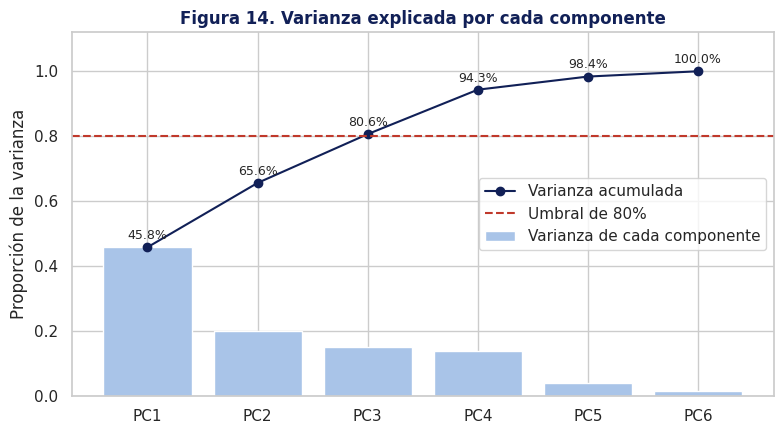

Varianza de cada componente: [0.458 0.198 0.15  0.137 0.04  0.016]
Componentes necesarias para llegar al 80%: 3 (acumulado 80.6%)


In [36]:
pca = PCA()
pca.fit(X_estandar)

varianza = pca.explained_variance_ratio_
varianza_acum = varianza.cumsum()
n_comp = int(np.argmax(varianza_acum >= 0.80)) + 1
componentes = np.arange(1, len(varianza) + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(componentes, varianza, color=AZUL_CLARO, label="Varianza de cada componente")
ax.plot(componentes, varianza_acum, marker="o", color=AZUL_OSCURO, label="Varianza acumulada")
ax.axhline(0.80, color=ROJO, ls="--", label="Umbral de 80%")
for c, v in zip(componentes, varianza_acum):
    ax.text(c, v + 0.025, f"{v:.1%}", ha="center", fontsize=9)
ax.set_xticks(componentes)
ax.set_xticklabels([f"PC{c}" for c in componentes])
ax.set_ylim(0, 1.12)
ax.set_ylabel("Proporción de la varianza")
ax.set_title("Figura 14. Varianza explicada por cada componente")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

print("Varianza de cada componente:", np.round(varianza, 3))
print(f"Componentes necesarias para llegar al 80%: {n_comp} (acumulado {varianza_acum[n_comp - 1]:.1%})")

**Figura 14.** La primera componente explica 45.8% de la varianza, la segunda 19.8% y la tercera 15.0%. Con tres se llega a 80.6%, así que el criterio del 80% se cumple con **3 componentes**, la mitad de las 6 variables originales. Con cuatro se llegaría a 94.3% y con cinco a 98.4%.

### Significado de cada componente

Cada componente es una combinación de las variables originales. Los pesos (*loadings*) indican cuánto aporta cada una.

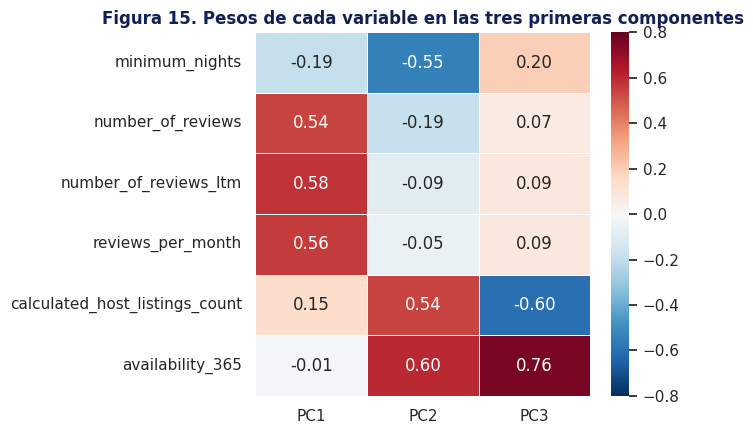

In [37]:
n = 3
pesos = pd.DataFrame(pca.components_[:n].T, index=vars_pca, columns=[f"PC{i + 1}" for i in range(n)])

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(pesos, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.8, vmax=0.8,
            linewidths=0.5, ax=ax)
ax.set_title("Figura 15. Pesos de cada variable en las tres primeras componentes")
plt.tight_layout()
plt.show()

**Figura 15.** Cada componente tiene una lectura distinta:

- **PC1 (45.8%): actividad de reseñas.** Las tres variables de reseñas aportan con pesos parecidos y positivos (0.54, 0.58 y 0.56), y las demás casi no pesan. Un valor alto indica un anuncio con muchas reseñas.
- **PC2 (19.8%): oferta abierta de anfitriones grandes con estancias cortas.** Suma `availability_365` (0.60) y `calculated_host_listings_count` (0.54), y resta `minimum_nights` (−0.55). Un valor alto indica un anuncio de un anfitrión con muchos anuncios, calendario abierto y estancia mínima corta.
- **PC3 (15.0%): contraste entre disponibilidad y tamaño del anfitrión.** `availability_365` pesa 0.76 y `calculated_host_listings_count` −0.60. Es la componente más difícil de interpretar.

Las componentes son mezclas de variables y se explican con menos claridad que las originales. PC1 y PC2 se pueden nombrar con confianza, y PC3 es más ambigua.

### Comparación antes y después

#### Correlaciones entre variables

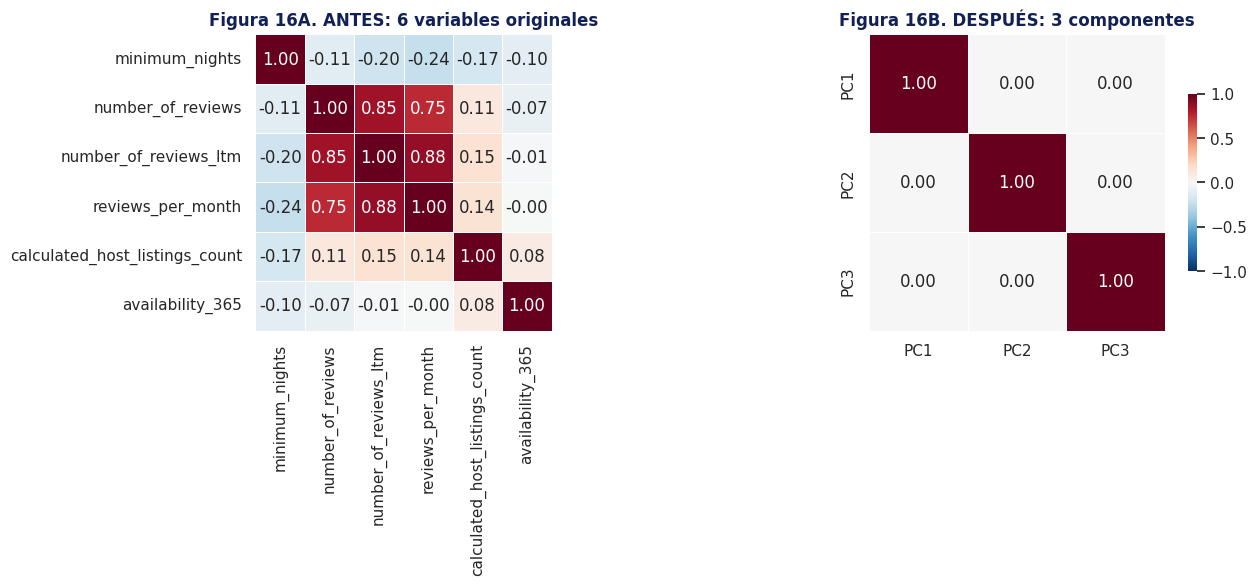

Pares de variables con |correlación| > 0.5 antes: 3 | correlación promedio absoluta: 0.26
Mayor |correlación| entre componentes después: 1.1e-16


In [38]:
componentes_df = pd.DataFrame(pca.transform(X_estandar)[:, :n], columns=[f"PC{i + 1}" for i in range(n)])
X_estandar_df = pd.DataFrame(X_estandar, columns=vars_pca)

corr_antes = X_estandar_df.corr()
corr_despues = componentes_df.corr()
corr_despues_plot = corr_despues.round(2) + 0.0  # evita mostrar -0.00

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})
sns.heatmap(corr_antes, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0], cbar=False, square=True)
axes[0].set_title("Figura 16A. ANTES: 6 variables originales")
sns.heatmap(corr_despues_plot, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[1], square=True, cbar_kws={"shrink": 0.6})
axes[1].set_title("Figura 16B. DESPUÉS: 3 componentes")
plt.tight_layout()
plt.show()

pares = corr_antes.where(np.triu(np.ones(corr_antes.shape, dtype=bool), 1)).stack().abs()
print(f"Pares de variables con |correlación| > 0.5 antes: {(pares > 0.5).sum()} | correlación promedio absoluta: {pares.mean():.2f}")
pares_d = corr_despues.where(np.triu(np.ones(corr_despues.shape, dtype=bool), 1)).stack().abs()
print(f"Mayor |correlación| entre componentes después: {pares_d.max():.2g}")

**Figura 16.** Antes (panel A), hay un bloque de tres variables fuertemente correlacionadas: `number_of_reviews_ltm` con `reviews_per_month` (0.88), `number_of_reviews` con `number_of_reviews_ltm` (0.85) y `number_of_reviews` con `reviews_per_month` (0.75). El resto de los pares es débil. Después (panel B), las tres componentes tienen correlación cero entre sí, y la redundancia desapareció. El PCA construye las componentes para que sean perpendiculares, y por eso son útiles si luego se quiere usar un modelo sensible a la colinealidad.

#### Forma de los datos

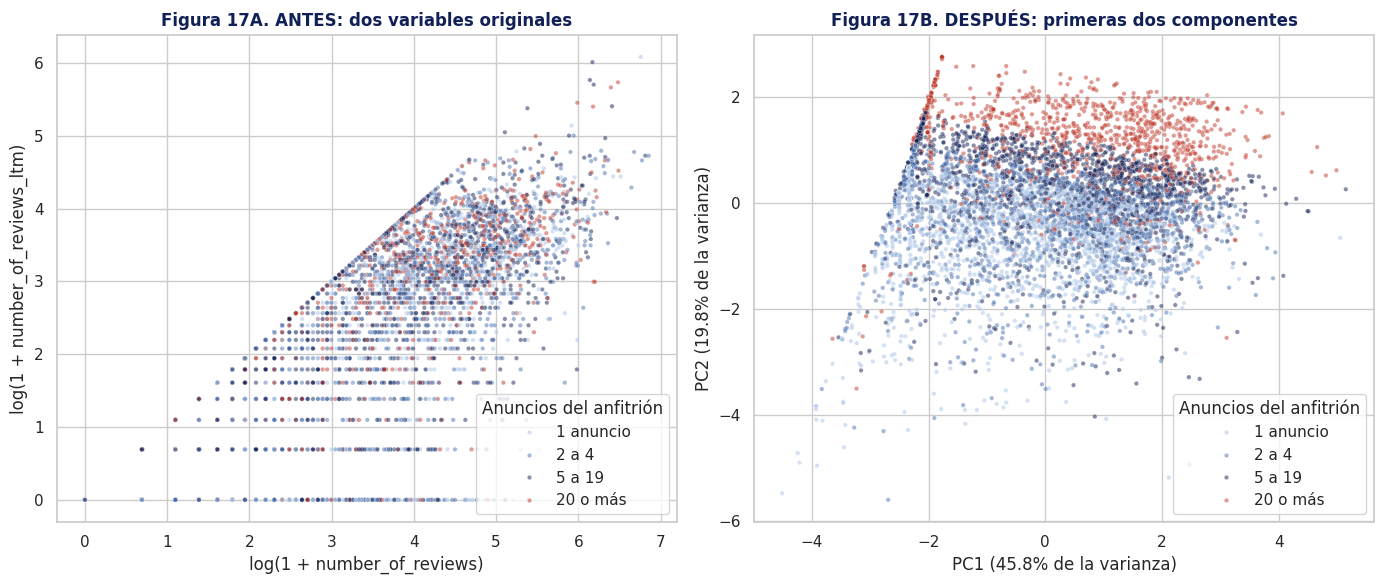

,PC1,PC2
Anuncios del anfitrión,,
1 anuncio,-0.59,-0.47
2 a 4,0.10,-0.19
5 a 19,0.42,0.38
20 o más,0.84,1.30


In [39]:
grupos = pd.cut(df_limpio["calculated_host_listings_count"], bins=[0, 1, 4, 19, np.inf],
                labels=["1 anuncio", "2 a 4", "5 a 19", "20 o más"])
paleta_grupos = {"1 anuncio": AZUL_CLARO, "2 a 4": AZUL, "5 a 19": AZUL_OSCURO, "20 o más": ROJO}

muestra = df_limpio.sample(6000, random_state=42).index
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=np.log1p(df_limpio.loc[muestra, "number_of_reviews"]),
                y=np.log1p(df_limpio.loc[muestra, "number_of_reviews_ltm"]),
                hue=grupos.loc[muestra], palette=paleta_grupos, s=10, alpha=0.5, ax=axes[0])
axes[0].set_title("Figura 17A. ANTES: dos variables originales")
axes[0].set_xlabel("log(1 + number_of_reviews)")
axes[0].set_ylabel("log(1 + number_of_reviews_ltm)")
axes[0].legend(title="Anuncios del anfitrión", loc="lower right")

sns.scatterplot(x=componentes_df.loc[muestra, "PC1"], y=componentes_df.loc[muestra, "PC2"],
                hue=grupos.loc[muestra], palette=paleta_grupos, s=10, alpha=0.5, ax=axes[1])
axes[1].set_title("Figura 17B. DESPUÉS: primeras dos componentes")
axes[1].set_xlabel(f"PC1 ({varianza[0]:.1%} de la varianza)")
axes[1].set_ylabel(f"PC2 ({varianza[1]:.1%} de la varianza)")
axes[1].legend(title="Anuncios del anfitrión", loc="lower right")

plt.tight_layout()
plt.show()

medianas = componentes_df.groupby(grupos.values, observed=True)[["PC1", "PC2"]].median().round(2)
medianas.index.name = "Anuncios del anfitrión"
medianas

**Figura 17.** Antes (panel A), las dos variables de reseñas suben juntas: los puntos forman una nube que crece en diagonal y que no puede pasar de la recta y = x, porque un anuncio no puede tener más reseñas en el último año que en total. Los dos ejes se mueven juntos y el segundo aporta poca información nueva. Después (panel B), la nube ya no sigue una diagonal y se reparte por el plano, porque PC1 y PC2 son independientes y cada eje aporta información distinta.

El color muestra que PC2 separa a los anfitriones por tamaño. La mediana de PC2 sube de −0.47 (anfitriones con un solo anuncio) a −0.19 (de 2 a 4), 0.38 (de 5 a 19) y 1.30 (20 o más). Es decir, aunque PC2 se construyó sin saber a qué grupo pertenece cada anuncio, recupera la diferencia entre anfitriones pequeños y profesionales. La separación no es total: los grupos se traslapan bastante.

In [40]:
logprecio = np.log10(df_limpio["price"])
print("Correlación de Pearson de cada componente con log10(price):")
for c in componentes_df.columns:
    print(f"  {c}: {componentes_df[c].corr(logprecio):.3f}")

print()
print("Mediana de PC1 por tipo de alojamiento:")
print(componentes_df.groupby(df_limpio["room_type"].values)["PC1"].median().round(2).sort_values().to_string())

Correlación de Pearson de cada componente con log10(price):
  PC1: -0.036
  PC2: 0.088
  PC3: -0.087

Mediana de PC1 por tipo de alojamiento:
Hotel room        -1.55
Private room      -0.67
Shared room       -0.67
Entire home/apt    0.46


### Conclusión de la reducción de dimensionalidad

El PCA resumió las 6 variables numéricas en **3 componentes que conservan 80.6% de la varianza** y no están correlacionadas entre sí. PC1 es un índice de actividad de reseñas (los cuartos de hotel tienen la mediana más baja y los alojamientos completos la más alta) y PC2 se relaciona con el tamaño del anfitrión.

| | Antes | Después |
|---|---|---|
| Variables | 6 originales (con un bloque de 3 muy correlacionadas) | 3 componentes |
| Varianza conservada | 100% | 80.6% |
| Pares con \|correlación\| > 0.5 | 3 | 0 |
| Interpretación | Directa | PC1 y PC2 claras, PC3 ambigua |

Se deben de considerar cierots límites, se pierde 19.4% de la varianza, y las componentes son menos fáciles de explicar que las variables originales. Además, ninguna de las tres componentes tiene una relación apreciable con el precio (correlaciones con `log10(price)` menores a 0.1 en valor absoluto, como en la matriz de la Figura 9), así que esta reducción ayuda a resumir la actividad y la escala del anfitrión, pero no a explicar el precio.

## Referencias

- Inside Airbnb. (2026, 15 de junio). *Mexico City, listings.csv (resumen)* [Conjunto de datos]. https://data.insideairbnb.com/mexico/df/mexico-city/2026-06-15/visualisations/listings.csv
- Inside Airbnb. (s.f.). *Get the Data*. Recuperado en octubre de 2026 de https://insideairbnb.com/get-the-data/
- Inside Airbnb. (s.f.). *Data Dictionary* [Hoja de cálculo]. https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?usp=sharing
- Creative Commons. (s.f.). *Attribution 4.0 International (CC BY 4.0)*. https://creativecommons.org/licenses/by/4.0/

### Declaración de uso de IA

Se utilizó Claude (Anthropic) como asistente para estructurar el notebook (Markdown) y revisar la redacción de los textos así como la depuración de código.